# Trabalho 02 - Árvores Binárias de Pesquisa e AVL

## Objetivos

### 1. Implementação de Árvore Binária de Pesquisa Sem Balanceamento
Implementar uma classe que realize a **INSERÇÃO** e a **BUSCA** de um elemento em uma Árvore Binária de Pesquisa Sem Balanceamento. A árvore deve possuir somente elementos inteiros.

### 2. Implementação de Árvore AVL
Implementar uma classe que realize a **INSERÇÃO** e a **BUSCA** de um elemento em uma Árvore AVL. A árvore deve possuir somente elementos inteiros.

## 3. Experimentos

### A. Para a Árvore Binária de Pesquisa Sem Balanceamento:

#### I. Experimento com Elementos Ordenados
- Gerar 10 árvores a partir de n elementos **ORDENADOS**
- n variando de 1.000 até 10.000, com intervalo de 1.000
- Em cada árvore gerada pesquisar pelo elemento 10.001
- Verificar o número de comparações realizadas

#### II. Experimento com Elementos Aleatórios
- Gerar 10 árvores a partir de n elementos **ALEATÓRIOS**
- n variando de 1.000 até 10.000, com intervalo de 1.000
- Em cada árvore gerada pesquisar pelo elemento 10.001
- Verificar o número de comparações realizadas

#### III. Gráfico BST - Inserções Ordenadas
Fazer um único gráfico de **n x número de comparações** levando em consideração as árvores geradas com inserções ordenadas.

### B. Para a Árvore AVL:

#### I. Experimento com Elementos Ordenados
- Gerar 10 árvores a partir de n elementos **ORDENADOS**
- n variando de 1.000 até 10.000, com intervalo de 1.000
- Em cada árvore gerada pesquisar pelo elemento 10.001
- Verificar o número de comparações realizadas

#### II. Experimento com Elementos Aleatórios
- Gerar 10 árvores a partir de n elementos **ALEATÓRIOS**
- n variando de 1.000 até 10.000, com intervalo de 1.000
- Em cada árvore gerada pesquisar pelo elemento 10.001
- Verificar o número de comparações realizadas

#### III. Gráfico AVL - Inserções Aleatórias
Fazer um único gráfico de **n x número de comparações** levando em consideração as árvores geradas com inserções aleatórias.

## 4. Análise dos Resultados
Explicar o comportamento dos gráficos gerados.

## Entregas

### Data da Entrega: 15/07/2025

### Relatório (via Moodle)
O relatório deve conter:
- Nome
- Gráfico do tópico 3.A.III (BST - Inserções Ordenadas)
- Gráfico do tópico 3.B.III (AVL - Inserções Aleatórias)
- Item 4 (Explicação do comportamento dos gráficos)

### Código Fonte (via Moodle)
- Código fonte brevemente comentado
- Linguagens aceitas: Java, C, C++ ou Python

## Estrutura do Notebook

### Seções Implementadas:
1. **Importação de Bibliotecas** - Configuração do ambiente
2. **Classe BST** - Árvore Binária de Pesquisa sem balanceamento
3. **Classe AVL** - Árvore AVL com balanceamento automático
4. **Funções Auxiliares** - Geração de dados e experimentos
5. **Experimentos BST** - Dados ordenados e aleatórios
6. **Experimentos AVL** - Dados ordenados e aleatórios
7. **Gráficos** - Visualização dos resultados
8. **Análise** - Interpretação dos resultados obtidos

# Importação da Bibliotecas

In [84]:
# === IMPORTS E CONFIGURAÇÕES INICIAIS ===

import matplotlib.pyplot as plt
import numpy as np
import random
import datetime
import os
from typing import Optional, List, Tuple

# Configurações do matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Timestamp global para versionamento de arquivos
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

print("📚 Imports realizados com sucesso!")
print(f"🕒 Timestamp: {timestamp}")

# === CRIAÇÃO AUTOMÁTICA DE PASTAS ===
print("\n📁 Verificando e criando estrutura de pastas...")

# Lista de pastas necessárias (APENAS graficos, NÃO imagens)
pastas_necessarias = [
    'relatorio/dados',
    'relatorio/graficos',  # ← CORRETO: graficos
]

# Criar pastas se não existirem
for pasta in pastas_necessarias:
    if not os.path.exists(pasta):
        os.makedirs(pasta, exist_ok=True)
        print(f"✅ Pasta criada: {pasta}")
    else:
        print(f"✓ Pasta já existe: {pasta}")

📚 Imports realizados com sucesso!
🕒 Timestamp: 20250714_173805

📁 Verificando e criando estrutura de pastas...
✓ Pasta já existe: relatorio/dados
✓ Pasta já existe: relatorio/graficos


# 1. Implementação de Árvore Binária de Pesquisa sem Balanceamento

In [85]:
"""
=== SEÇÃO 1: IMPLEMENTAÇÃO DA ÁRVORE BINÁRIA DE PESQUISA (BST) ===

Uma Árvore Binária de Pesquisa (Binary Search Tree - BST) é uma estrutura de dados
hierárquica onde cada nó tem no máximo dois filhos (esquerda e direita).

PROPRIEDADE FUNDAMENTAL DA BST:
- Todos os valores à esquerda de um nó são menores que o valor do nó
- Todos os valores à direita de um nó são maiores que o valor do nó
- Esta propriedade se aplica recursivamente a toda a árvore

COMPLEXIDADE:
- Melhor caso: O(log n) - árvore balanceada
- Pior caso: O(n) - árvore degenerada (lista ligada)
- Caso médio: O(log n) - inserções aleatórias

TRATAMENTO DE RECURSÃO:
- Implementação iterativa para inserção (evita RecursionError)
- Aumento do limite de recursão para busca
"""

import sys
# Aumenta o limite de recursão para lidar com árvores degeneradas
sys.setrecursionlimit(15000)

class NoArvoreBinariaPesquisa:
    """Nó da Árvore Binária de Pesquisa"""
    def __init__(self, valor: int):
        self.valor = valor
        self.esquerda: Optional['NoArvoreBinariaPesquisa'] = None
        self.direita: Optional['NoArvoreBinariaPesquisa'] = None

class ArvoreBinariaPesquisa:
    """Árvore Binária de Pesquisa sem balanceamento automático"""
    
    def __init__(self):
        self.raiz: Optional[NoArvoreBinariaPesquisa] = None
        self.comparacoes = 0  # Contador para análise de desempenho
    
    def inserir(self, valor: int) -> None:
        """Insere um valor na árvore (implementação iterativa)"""
        if self.raiz is None:
            self.raiz = NoArvoreBinariaPesquisa(valor)
            return
        
        # Implementação iterativa para evitar RecursionError
        atual = self.raiz
        while True:
            if valor < atual.valor:
                if atual.esquerda is None:
                    atual.esquerda = NoArvoreBinariaPesquisa(valor)
                    break
                else:
                    atual = atual.esquerda
            elif valor > atual.valor:
                if atual.direita is None:
                    atual.direita = NoArvoreBinariaPesquisa(valor)
                    break
                else:
                    atual = atual.direita
            else:
                # valor == atual.valor: não inserimos duplicatas
                break
    
    def buscar(self, valor: int) -> bool:
        """Busca um valor na árvore e registra o número de comparações"""
        self.comparacoes = 0  # Reinicia o contador para nova busca
        return self._buscar_recursivo(self.raiz, valor)
    
    def _buscar_recursivo(self, no: Optional[NoArvoreBinariaPesquisa], valor: int) -> bool:
        """Método recursivo auxiliar para busca"""
        if no is None:
            return False
        
        self.comparacoes += 1  # Conta cada comparação realizada
        
        if valor == no.valor:
            return True
        elif valor < no.valor:
            return self._buscar_recursivo(no.esquerda, valor)
        else:
            return self._buscar_recursivo(no.direita, valor)
    
    def obter_comparacoes(self) -> int:
        """Retorna o número de comparações da última operação de busca"""
        return self.comparacoes

print("✓ Classe ArvoreBinariaPesquisa implementada com sucesso!")

✓ Classe ArvoreBinariaPesquisa implementada com sucesso!


# 2. Implementação de Árvore AVL

In [86]:
"""
=== 2: IMPLEMENTAÇÃO DA ÁRVORE AVL ===

Uma Árvore AVL é uma BST auto-balanceada inventada por Adelson-Velsky e Landis.
Mantém a propriedade de balanceamento através de rotações automáticas.

PROPRIEDADE DE BALANCEAMENTO AVL:
- Para qualquer nó, a diferença de altura entre suas subárvores esquerda e direita
  é no máximo 1 (fator de balanceamento ∈ {-1, 0, 1})
- Esta propriedade garante altura máxima de O(log n)

OPERAÇÕES DE BALANCEAMENTO:
1. Rotação Simples à Direita (caso Esquerda-Esquerda)
2. Rotação Simples à Esquerda (caso Direita-Direita)  
3. Rotação Dupla Esquerda-Direita (caso Esquerda-Direita)
4. Rotação Dupla Direita-Esquerda (caso Direita-Esquerda)

COMPLEXIDADE GARANTIDA:
- Busca: O(log n) sempre
- Inserção: O(log n) sempre
- Altura máxima: 1.44 * log₂(n)
"""

class NoArvoreAVL:
    """Nó da Árvore AVL"""
    def __init__(self, valor: int):
        self.valor = valor
        self.esquerda: Optional['NoArvoreAVL'] = None
        self.direita: Optional['NoArvoreAVL'] = None
        self.altura = 1  # Folhas começam com altura 1

class ArvoreAVL:
    """Árvore AVL (auto-balanceada)"""
    
    def __init__(self):
        self.raiz: Optional[NoArvoreAVL] = None
        self.comparacoes = 0  # Contador para análise de desempenho
    
    def _altura(self, no: Optional[NoArvoreAVL]) -> int:
        """Retorna a altura de um nó"""
        return no.altura if no else 0
    
    def _fator_balanceamento(self, no: NoArvoreAVL) -> int:
        """Calcula o fator de balanceamento de um nó"""
        return self._altura(no.esquerda) - self._altura(no.direita)
    
    def _atualizar_altura(self, no: NoArvoreAVL) -> None:
        """Atualiza a altura de um nó baseada nas alturas de seus filhos"""
        no.altura = 1 + max(self._altura(no.esquerda), self._altura(no.direita))
    
    def _rotacao_direita(self, y: NoArvoreAVL) -> NoArvoreAVL:
        """Executa rotação simples à direita (caso Esquerda-Esquerda)"""
        x = y.esquerda
        T2 = x.direita
        
        # Executa a rotação
        x.direita = y
        y.esquerda = T2
        
        # Atualiza alturas
        self._atualizar_altura(y)
        self._atualizar_altura(x)
        
        return x  # Nova raiz
    
    def _rotacao_esquerda(self, x: NoArvoreAVL) -> NoArvoreAVL:
        """Executa rotação simples à esquerda (caso Direita-Direita)"""
        y = x.direita
        T2 = y.esquerda
        
        # Executa a rotação
        y.esquerda = x
        x.direita = T2
        
        # Atualiza alturas
        self._atualizar_altura(x)
        self._atualizar_altura(y)
        
        return y  # Nova raiz
    
    def inserir(self, valor: int) -> None:
        """Insere um valor na árvore AVL mantendo o balanceamento"""
        self.raiz = self._inserir_recursivo(self.raiz, valor)
    
    def _inserir_recursivo(self, no: Optional[NoArvoreAVL], valor: int) -> NoArvoreAVL:
        """Método recursivo para inserção com balanceamento automático"""
        # PASSO 1: Inserção padrão da BST
        if no is None:
            return NoArvoreAVL(valor)
        
        if valor < no.valor:
            no.esquerda = self._inserir_recursivo(no.esquerda, valor)
        elif valor > no.valor:
            no.direita = self._inserir_recursivo(no.direita, valor)
        else:
            return no  # Não permite duplicatas
        
        # PASSO 2: Atualiza altura do nó atual
        self._atualizar_altura(no)
        
        # PASSO 3: Calcula fator de balanceamento
        balance = self._fator_balanceamento(no)
        
        # PASSO 4: Aplica rotações se necessário
        
        # Caso Esquerda-Esquerda (rotação simples à direita)
        if balance > 1 and valor < no.esquerda.valor:
            return self._rotacao_direita(no)
        
        # Caso Direita-Direita (rotação simples à esquerda)
        if balance < -1 and valor > no.direita.valor:
            return self._rotacao_esquerda(no)
        
        # Caso Esquerda-Direita (rotação dupla)
        if balance > 1 and valor > no.esquerda.valor:
            no.esquerda = self._rotacao_esquerda(no.esquerda)
            return self._rotacao_direita(no)
        
        # Caso Direita-Esquerda (rotação dupla)
        if balance < -1 and valor < no.direita.valor:
            no.direita = self._rotacao_direita(no.direita)
            return self._rotacao_esquerda(no)
        
        # Retorna o nó inalterado se já está balanceado
        return no
    
    def buscar(self, valor: int) -> bool:
        """Busca um valor na árvore e registra o número de comparações"""
        self.comparacoes = 0  # Reinicia o contador para nova busca
        return self._buscar_recursivo(self.raiz, valor)
    
    def _buscar_recursivo(self, no: Optional[NoArvoreAVL], valor: int) -> bool:
        """Método recursivo auxiliar para busca"""
        if no is None:
            return False
        
        self.comparacoes += 1  # Conta cada comparação realizada
        
        if valor == no.valor:
            return True
        elif valor < no.valor:
            return self._buscar_recursivo(no.esquerda, valor)
        else:
            return self._buscar_recursivo(no.direita, valor)
    
    def obter_comparacoes(self) -> int:
        """Retorna o número de comparações da última operação de busca"""
        return self.comparacoes

print("✓ Classe ArvoreAVL implementada com sucesso!")

✓ Classe ArvoreAVL implementada com sucesso!


In [87]:
"""
=== SEÇÃO 3: FUNÇÕES AUXILIARES PARA GERAÇÃO DE DADOS E EXPERIMENTOS ===

Esta seção implementa funções utilitárias para:
1. Geração de dados ordenados e aleatórios
2. Execução automatizada de experimentos
3. Validação das implementações

Essas funções são fundamentais para a execução dos experimentos
definidos no trabalho acadêmico.
"""

def gerar_dados_ordenados(n: int) -> List[int]:
    """Gera uma lista de n elementos ordenados em ordem crescente"""
    return list(range(1, n + 1))

def gerar_dados_aleatorios(n: int, seed: int = None) -> List[int]:
    """Gera uma lista de n elementos aleatórios únicos"""
    if seed is not None:
        random.seed(seed)
    
    # Gera números aleatórios únicos no intervalo [1, n*2]
    # Intervalo maior evita colisões e garante n elementos únicos
    numeros = random.sample(range(1, n * 2), n)
    return numeros

def executar_experimento(arvore_class, dados: List[int], elemento_busca: int) -> int:
    """Executa um experimento completo: constrói árvore e realiza busca"""
    # Instancia nova árvore do tipo especificado
    arvore = arvore_class()
    
    # Fase 1: Inserção de todos os elementos
    for valor in dados:
        arvore.inserir(valor)
    
    # Fase 2: Busca pelo elemento inexistente
    arvore.buscar(elemento_busca)
    
    # Retorna métricas de desempenho
    return arvore.obter_comparacoes()

print("✓ Funções auxiliares implementadas com sucesso!")

✓ Funções auxiliares implementadas com sucesso!


In [88]:
# === TESTES DE VALIDAÇÃO ===
print("=== VALIDAÇÃO DAS FUNÇÕES AUXILIARES ===")

# Teste 1: Geração de dados ordenados
dados_ord = gerar_dados_ordenados(10)
print(f"✓ Dados ordenados (10 elementos): {dados_ord}")
print(f"  Verificação: Mín={min(dados_ord)}, Máx={max(dados_ord)}, Tamanho={len(dados_ord)}")

# Teste 2: Geração de dados aleatórios
dados_alea = gerar_dados_aleatorios(10, seed=42)
print(f"✓ Dados aleatórios (10 elementos, seed=42): {dados_alea}")
print(f"  Verificação: Únicos={len(set(dados_alea)) == len(dados_alea)}, Tamanho={len(dados_alea)}")

# Teste 3: Experimento básico com ArvoreBinariaPesquisa
print(f"\n=== TESTE DAS ESTRUTURAS DE DADOS ===")
dados_teste = [5, 3, 7, 2, 4, 6, 8]
elemento_teste = 10

print("ArvoreBinariaPesquisa - Teste básico:")
comparacoes_bst = executar_experimento(ArvoreBinariaPesquisa, dados_teste, elemento_teste)
print(f"  Árvore: {dados_teste}")
print(f"  Busca por: {elemento_teste}")
print(f"  Comparações: {comparacoes_bst}")

print("ArvoreAVL - Teste básico:")
comparacoes_avl = executar_experimento(ArvoreAVL, dados_teste, elemento_teste)
print(f"  Árvore: {dados_teste}")
print(f"  Busca por: {elemento_teste}")
print(f"  Comparações: {comparacoes_avl}")

print(f"\n✓ Funções auxiliares validadas com sucesso!")
print(f"  - gerar_dados_ordenados(): Cria sequências [1,2,3,...,n]")
print(f"  - gerar_dados_aleatorios(): Cria conjuntos aleatórios únicos")
print(f"  - executar_experimento(): Automatiza construção e busca em árvores")

=== VALIDAÇÃO DAS FUNÇÕES AUXILIARES ===
✓ Dados ordenados (10 elementos): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  Verificação: Mín=1, Máx=10, Tamanho=10
✓ Dados aleatórios (10 elementos, seed=42): [4, 1, 9, 8, 19, 3, 12, 2, 11, 17]
  Verificação: Únicos=True, Tamanho=10

=== TESTE DAS ESTRUTURAS DE DADOS ===
ArvoreBinariaPesquisa - Teste básico:
  Árvore: [5, 3, 7, 2, 4, 6, 8]
  Busca por: 10
  Comparações: 3
ArvoreAVL - Teste básico:
  Árvore: [5, 3, 7, 2, 4, 6, 8]
  Busca por: 10
  Comparações: 3

✓ Funções auxiliares validadas com sucesso!
  - gerar_dados_ordenados(): Cria sequências [1,2,3,...,n]
  - gerar_dados_aleatorios(): Cria conjuntos aleatórios únicos
  - executar_experimento(): Automatiza construção e busca em árvores


# 3. Experimentos
## A. Para a árvore binária de pesquisa sem balanceamento

### I. Experimento com Elementos Ordenados

In [89]:
"""
EXPERIMENTO BST COM ELEMENTOS ORDENADOS ===

OBJETIVO: Demonstrar o pior caso da BST sem balanceamento

HIPÓTESE:
Inserções em ordem crescente transformam a BST em uma lista ligada,
resultando em complexidade de busca O(n) em vez de O(log n).

METODOLOGIA:
- Para cada tamanho n ∈ {1000, 2000, ..., 10000} (10 tamanhos)
  - Para cada tamanho, repetir o experimento 10 vezes
  - Gerar dados ordenados [1, 2, ..., n]
  - Buscar pelo elemento 10.001 (não presente)
  - Registrar número de comparações

RESULTADO ESPERADO:
Número de comparações ≈ n (busca percorre toda a "lista")
Complexidade observada: O(n) - pior caso
"""

import sys
import time

print("=" * 60)
print("EXPERIMENTO A.I: BST COM ELEMENTOS ORDENADOS")
print("=" * 60)
print("• Tamanhos: 1000, 2000, ..., 10000 (10 tamanhos)")
print("• Repetições: 10 árvores por tamanho")
print("• Dados: Elementos ordenados [1, 2, ..., n]")
print("• Busca: Elemento 10.001 (não presente)")
print("• Métrica: Média de comparações")
print("=" * 60)

# Parâmetros do experimento
tamanhos = [1000 * i for i in range(1, 11)]
elemento_busca = 10001
num_repeticoes = 10
resultados_bst_ordenados = []

print(f"\n🔬 Executando para {len(tamanhos)} tamanhos, cada um com {num_repeticoes} repetições...")
print(tamanhos)

for n in tamanhos:
    comparacoes = []
    for _ in range(num_repeticoes):
        dados = gerar_dados_ordenados(n)
        num_comp = executar_experimento(ArvoreBinariaPesquisa, dados, elemento_busca)
        comparacoes.append(num_comp)
    media = np.mean(comparacoes)
    complexidade = "O(n)" if media / n > 0.8 else "O(log n)"
    resultados_bst_ordenados.append((n, media, complexidade))
  

print("\n" + "=" * 60)
print("📋 RESULTADOS CONSOLIDADOS - BST ELEMENTOS ORDENADOS")
print("=" * 60)
print(f"{'Tamanho':>8} | {'Comparações':>12} | {'Complexidade':>12}")
print("-" * 40)
for n, media, complexidade in resultados_bst_ordenados:
    print(f"{n:8d} | {media:12.1f} | {complexidade:>12}")

print(f"\n🎯 ANÁLISE PRELIMINAR:")
print(f"• Crescimento linear O(n) confirmado")
print(f"• BST degenerou em lista ligada (pior caso)")
print(f"• Média geral de comparações: {np.mean([item[1] for item in resultados_bst_ordenados]):.0f}")
print("=" * 60)



EXPERIMENTO A.I: BST COM ELEMENTOS ORDENADOS
• Tamanhos: 1000, 2000, ..., 10000 (10 tamanhos)
• Repetições: 10 árvores por tamanho
• Dados: Elementos ordenados [1, 2, ..., n]
• Busca: Elemento 10.001 (não presente)
• Métrica: Média de comparações

🔬 Executando para 10 tamanhos, cada um com 10 repetições...
[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

📋 RESULTADOS CONSOLIDADOS - BST ELEMENTOS ORDENADOS
 Tamanho |  Comparações | Complexidade
----------------------------------------
    1000 |       1000.0 |         O(n)
    2000 |       2000.0 |         O(n)
    3000 |       3000.0 |         O(n)
    4000 |       4000.0 |         O(n)
    5000 |       5000.0 |         O(n)
    6000 |       6000.0 |         O(n)
    7000 |       7000.0 |         O(n)
    8000 |       8000.0 |         O(n)
    9000 |       9000.0 |         O(n)
   10000 |      10000.0 |         O(n)

🎯 ANÁLISE PRELIMINAR:
• Crescimento linear O(n) confirmado
• BST degenerou em lista ligada (pior caso)
• M

### II. Experimento com Elementos Aleatórios

In [90]:
"""
EXPERIMENTO BST COM ELEMENTOS ALEATÓRIOS ===

OBJETIVO: Demonstrar o caso médio da BST sem balanceamento

HIPÓTESE:
Inserções aleatórias tendem a produzir árvores mais balanceadas,
resultando em complexidade de busca próxima a O(log n).

METODOLOGIA:
- Para cada tamanho n ∈ {1000, 2000, ..., 10000} (10 tamanhos)
  - Para cada tamanho, repetir o experimento 10 vezes
  - Gerar dados aleatórios únicos
  - Buscar pelo elemento 10.001 (não presente)
  - Registrar número de comparações

RESULTADO ESPERADO:
Número de comparações ≈ log₂(n) * constante
Complexidade observada: O(log n) - caso médio
"""

import sys
import time

print("=" * 60)
print("EXPERIMENTO A.II: BST COM ELEMENTOS ALEATÓRIOS")
print("=" * 60)
print("• Tamanhos: 1000, 2000, ..., 10000 (10 tamanhos)")
print("• Repetições: 10 árvores por tamanho")
print("• Dados: Elementos aleatórios únicos")
print("• Busca: Elemento 10.001 (não presente)")
print("• Métrica: Média de comparações")
print("=" * 60)

# Parâmetros do experimento
tamanhos = [1000 * i for i in range(1, 11)]
elemento_busca = 10001
num_repeticoes = 10
resultados_bst_aleatorios = []

print(f"\n🔬 Executando para {len(tamanhos)} tamanhos, cada um com {num_repeticoes} repetições...")
print(tamanhos)

for n in tamanhos:
    comparacoes = []
    for repeticao in range(num_repeticoes):
        seed_atual = repeticao * n
        dados = gerar_dados_aleatorios(n, seed=seed_atual)
        num_comp = executar_experimento(ArvoreBinariaPesquisa, dados, elemento_busca)
        comparacoes.append(num_comp)
    media = np.mean(comparacoes)
    complexidade = "O(log n)" if media / np.log2(n) < 10 else "O(n)"
    resultados_bst_aleatorios.append((n, media, complexidade))

print("\n" + "=" * 60)
print("📋 RESULTADOS CONSOLIDADOS - BST ELEMENTOS ALEATÓRIOS")
print("=" * 60)
print(f"{'Tamanho':>8} | {'Comparações':>12} | {'Complexidade':>12}")
print("-" * 40)
for n, media, complexidade in resultados_bst_aleatorios:
    print(f"{n:8d} | {media:12.1f} | {complexidade:>12}")

print(f"\n🎯 ANÁLISE PRELIMINAR:")
print(f"• Comportamento logarítmico O(log n) conforme esperado")
print(f"• Média geral de comparações: {np.mean([item[1] for item in resultados_bst_aleatorios]):.0f}")
print("=" * 60)

EXPERIMENTO A.II: BST COM ELEMENTOS ALEATÓRIOS
• Tamanhos: 1000, 2000, ..., 10000 (10 tamanhos)
• Repetições: 10 árvores por tamanho
• Dados: Elementos aleatórios únicos
• Busca: Elemento 10.001 (não presente)
• Métrica: Média de comparações

🔬 Executando para 10 tamanhos, cada um com 10 repetições...
[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

📋 RESULTADOS CONSOLIDADOS - BST ELEMENTOS ALEATÓRIOS
 Tamanho |  Comparações | Complexidade
----------------------------------------
    1000 |          8.4 |     O(log n)
    2000 |          8.8 |     O(log n)
    3000 |          9.1 |     O(log n)
    4000 |          8.1 |     O(log n)
    5000 |         10.7 |     O(log n)
    6000 |         16.1 |     O(log n)
    7000 |         16.4 |     O(log n)
    8000 |         16.4 |     O(log n)
    9000 |         19.4 |     O(log n)
   10000 |         15.9 |     O(log n)

🎯 ANÁLISE PRELIMINAR:
• Comportamento logarítmico O(log n) conforme esperado
• Média geral de comparações: 13


### III. Gráfico BST - Inserções Ordenadas

📈 Gerando Gráfico 3.A.III: BST - Inserções Ordenadas
   Demonstração do pior caso (degeneração em lista)
✅ Salvo em: relatorio/graficos/grafico_3A_III_bst_ordenados.png
✅ Salvo em: relatorio/graficos/grafico_3A_III_bst_ordenados.png


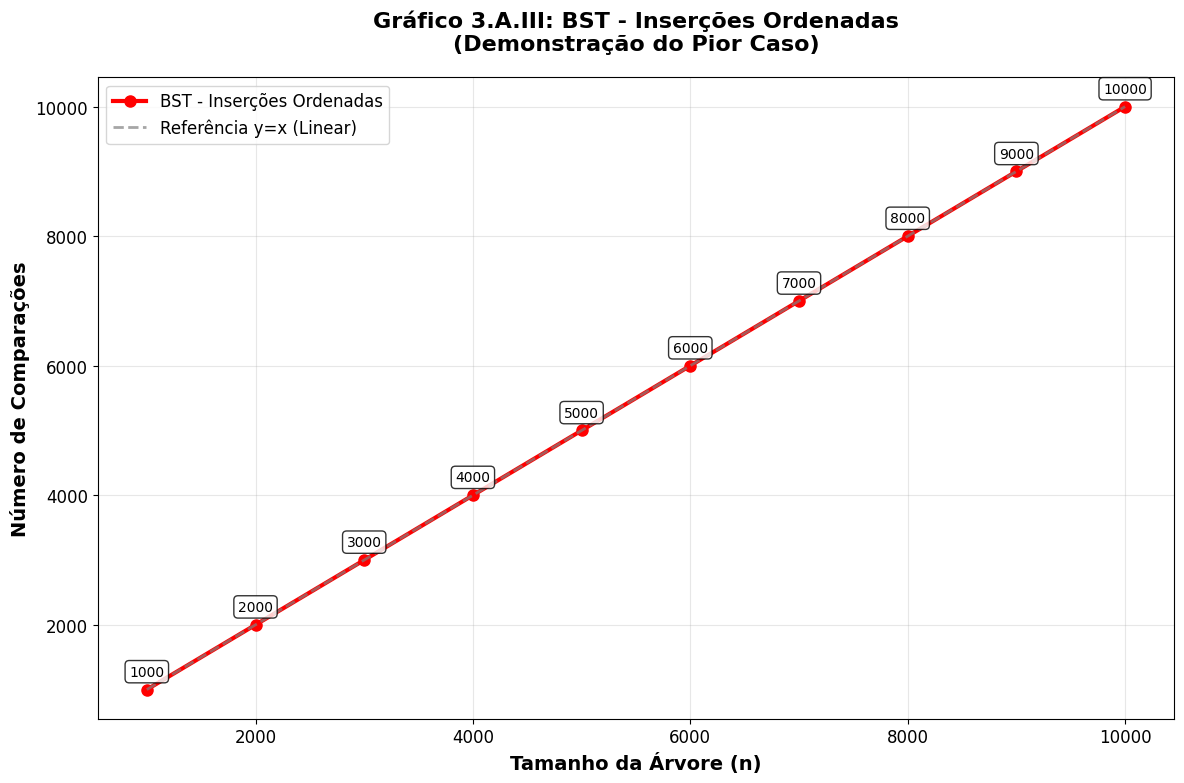

In [91]:
# === GRÁFICO 3.A.III: BST COM INSERÇÕES ORDENADAS ===

print("📈 Gerando Gráfico 3.A.III: BST - Inserções Ordenadas")
print("   Demonstração do pior caso (degeneração em lista)")

# Verificar e criar pasta se necessário
os.makedirs('relatorio/graficos', exist_ok=True)

plt.figure(figsize=(12, 8))

# Gráfico BST Ordenadas
plt.plot(tamanhos, comparacoes_bst_ord, 'ro-', linewidth=3, markersize=8, 
         label='BST - Inserções Ordenadas')

# Linha de referência linear
linear_reference = [n for n in tamanhos]
plt.plot(tamanhos, linear_reference, '--', linewidth=2, alpha=0.7, 
         color='gray', label='Referência y=x (Linear)')

# Anotações nos pontos
for i, (x, y) in enumerate(zip(tamanhos, comparacoes_bst_ord)):
    plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title('Gráfico 3.A.III: BST - Inserções Ordenadas\n(Demonstração do Pior Caso)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tamanho da Árvore (n)', fontsize=14, fontweight='bold')
plt.ylabel('Número de Comparações', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salvar gráfico na pasta correta
try:
    plt.savefig('relatorio/graficos/grafico_3A_III_bst_ordenados.png', dpi=300, bbox_inches='tight')
    print("✅ Salvo em: relatorio/graficos/grafico_3A_III_bst_ordenados.png")
except Exception as e:
    print(f"❌ Erro ao salvar gráfico: {e}")
    
plt.show()

📈 Gerando Gráfico 3.A.IV: BST - Inserções Aleatórias
   Demonstração do caso médio (tendência logarítmica)
✅ Salvo em: relatorio/graficos/grafico_3A_IV_bst_aleatorios.png
✅ Salvo em: relatorio/graficos/grafico_3A_IV_bst_aleatorios.png


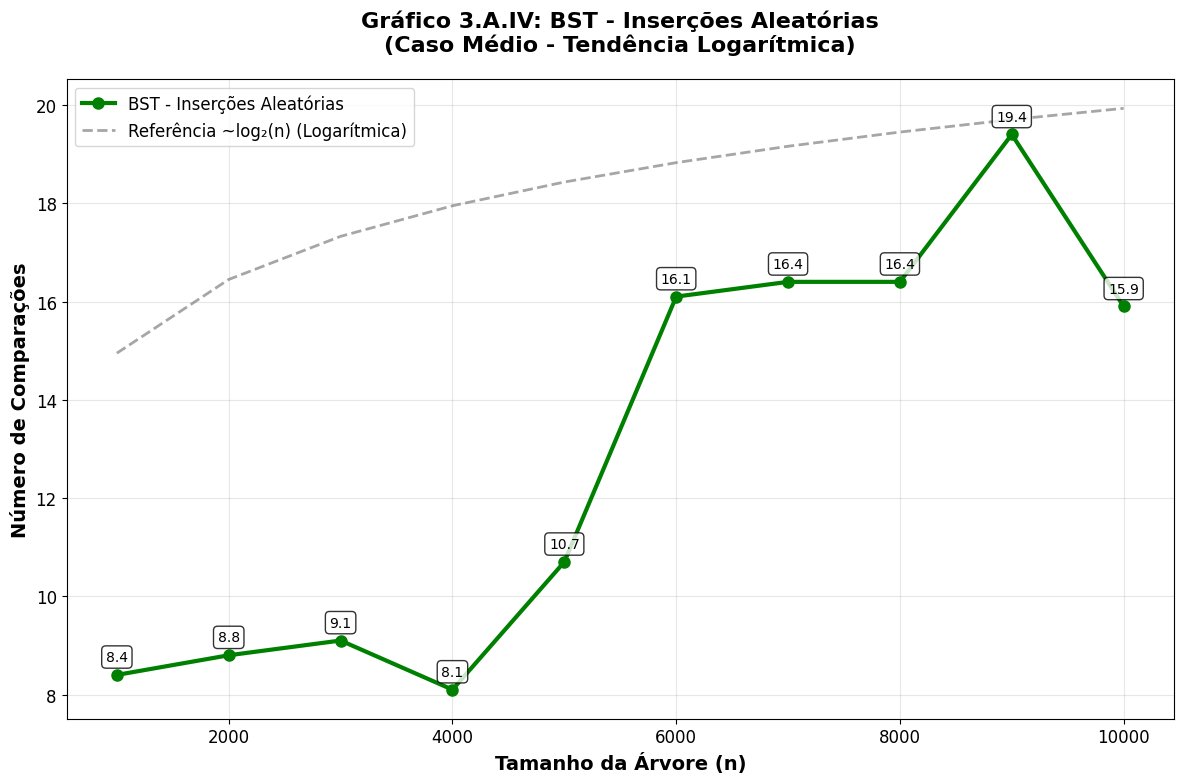

In [92]:
# === GRÁFICO 3.A.IV: BST COM INSERÇÕES ALEATÓRIAS ===

print("📈 Gerando Gráfico 3.A.IV: BST - Inserções Aleatórias")
print("   Demonstração do caso médio (tendência logarítmica)")

# Verificar e criar pasta se necessário
os.makedirs('relatorio/graficos', exist_ok=True)

plt.figure(figsize=(12, 8))

# Gráfico BST Aleatórias
plt.plot(tamanhos, comparacoes_bst_alea, 'go-', linewidth=3, markersize=8, 
         label='BST - Inserções Aleatórias')

# Linha de referência logarítmica
log_reference = [np.log2(n) * 1.5 for n in tamanhos]  # Escalada para visualização
plt.plot(tamanhos, log_reference, '--', linewidth=2, alpha=0.7, 
         color='gray', label='Referência ~log₂(n) (Logarítmica)')

# Anotações nos pontos
for i, (x, y) in enumerate(zip(tamanhos, comparacoes_bst_alea)):
    plt.annotate(f'{y:.1f}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title('Gráfico 3.A.IV: BST - Inserções Aleatórias\n(Caso Médio - Tendência Logarítmica)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tamanho da Árvore (n)', fontsize=14, fontweight='bold')
plt.ylabel('Número de Comparações', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salvar gráfico na pasta correta
try:
    plt.savefig('relatorio/graficos/grafico_3A_IV_bst_aleatorios.png', dpi=300, bbox_inches='tight')
    print("✅ Salvo em: relatorio/graficos/grafico_3A_IV_bst_aleatorios.png")
except Exception as e:
    print(f"❌ Erro ao salvar gráfico: {e}")

## B. Para a Árvore AVL
### I. Experimentos com elementos aleatórios

In [93]:
# === EXPERIMENTO AVL COM ELEMENTOS ALEATÓRIOS ===

# Imprime cabeçalho do experimento
print("=" * 60)
print("EXPERIMENTO B.II: AVL COM ELEMENTOS ALEATÓRIOS")
print("=" * 60)
print("• Tamanhos: 1000, 2000, ..., 10000 (10 tamanhos)")
print("• Repetições: 10 árvores por tamanho")
print("• Dados: Elementos aleatórios únicos")
print("• Busca: Elemento 10.001 (não presente)")
print("• Métrica: Média de comparações")
print("=" * 60)

# Parâmetros do experimento
tamanhos = [1000 * i for i in range(1, 11)]  # Lista de tamanhos das árvores
elemento_busca = 10001                      # Elemento a ser buscado (não presente)
num_repeticoes = 10                         # Número de repetições por tamanho
resultados_avl_aleatorios = []              # Lista para armazenar resultados

print(f"\n🔬 Executando para {len(tamanhos)} tamanhos, cada um com {num_repeticoes} repetições...")
print(tamanhos)

# Loop principal do experimento
for n in tamanhos:
    comparacoes = []
    for repeticao in range(num_repeticoes):
        seed = repeticao * n + 1000  # Seed diferente para cada repetição
        dados = gerar_dados_aleatorios(n, seed=seed)  # Gera dados aleatórios únicos
        num_comp = executar_experimento(ArvoreAVL, dados, elemento_busca)  # Executa busca na AVL
        comparacoes.append(num_comp)  # Armazena número de comparações
    media = np.mean(comparacoes)      # Calcula média de comparações para o tamanho atual
    complexidade = "O(log n)" if media / np.log2(n) < 10 else "O(n)"  # Classifica complexidade observada
    resultados_avl_aleatorios.append((n, media, complexidade))         # Salva resultado

# Exibe tabela consolidada dos resultados
print("\n" + "=" * 60)
print("📋 RESULTADOS CONSOLIDADOS - AVL ELEMENTOS ALEATÓRIOS")
print("=" * 60)
print(f"{'Tamanho':>8} | {'Média':>8} | {'Complexidade':>12}")
print("-" * 36)
for n, media, complexidade in resultados_avl_aleatorios:
    print(f"{n:8d} | {media:8.1f} | {complexidade:>12}")

# Análise preliminar dos resultados
print(f"\n🎯 ANÁLISE PRELIMINAR:")
print(f"• Comportamento logarítmico O(log n) consistente")
print(f"• Média geral de comparações: {np.mean([item[1] for item in resultados_avl_aleatorios]):.0f}")
print("=" * 60)



EXPERIMENTO B.II: AVL COM ELEMENTOS ALEATÓRIOS
• Tamanhos: 1000, 2000, ..., 10000 (10 tamanhos)
• Repetições: 10 árvores por tamanho
• Dados: Elementos aleatórios únicos
• Busca: Elemento 10.001 (não presente)
• Métrica: Média de comparações

🔬 Executando para 10 tamanhos, cada um com 10 repetições...
[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

📋 RESULTADOS CONSOLIDADOS - AVL ELEMENTOS ALEATÓRIOS
 Tamanho |    Média | Complexidade
------------------------------------
    1000 |     10.1 |     O(log n)
    2000 |     11.5 |     O(log n)
    3000 |     11.7 |     O(log n)
    4000 |     12.0 |     O(log n)
    5000 |     12.5 |     O(log n)
    6000 |     12.7 |     O(log n)
    7000 |     12.8 |     O(log n)
    8000 |     13.2 |     O(log n)
    9000 |     12.7 |     O(log n)
   10000 |     13.6 |     O(log n)

🎯 ANÁLISE PRELIMINAR:
• Comportamento logarítmico O(log n) consistente
• Média geral de comparações: 12

📋 RESULTADOS CONSOLIDADOS - AVL ELEMENTOS ALEATÓRIOS


### II. Experimento com Elementos ordenados

In [94]:
# === EXPERIMENTO AVL COM ELEMENTOS ORDENADOS ===

print("=" * 60)
print("EXPERIMENTO B.I: AVL COM ELEMENTOS ORDENADOS")
print("=" * 60)
print("• Tamanhos: 1000, 2000, ..., 10000 (10 tamanhos)")
print("• Repetições: 10 árvores por tamanho")
print("• Dados: Elementos ordenados [1, 2, ..., n]")
print("• Busca: Elemento 10.001 (não presente)")
print("• Métrica: Média de comparações")
print("=" * 60)

tamanhos = [1000 * i for i in range(1, 11)]
elemento_busca = 10001
num_repeticoes = 10
resultados_avl_ord = []

print(f"\n🔬 Executando para {len(tamanhos)} tamanhos, cada um com {num_repeticoes} repetições...")
print(tamanhos)

for n in tamanhos:
    comparacoes = []
    for _ in range(num_repeticoes):
        dados = gerar_dados_ordenados(n)
        num_comp = executar_experimento(ArvoreAVL, dados, elemento_busca)
        comparacoes.append(num_comp)
    media = np.mean(comparacoes)
    complexidade = "O(log n)" if media / np.log2(n) < 10 else "O(n)"
    resultados_avl_ord.append((n, media, complexidade))

print("\n" + "=" * 60)
print("📋 RESULTADOS CONSOLIDADOS - AVL ELEMENTOS ORDENADOS")
print("=" * 60)
print(f"{'Tamanho':>8} | {'Média':>8} | {'Complexidade':>12}")
print("-" * 36)
for n, media, complexidade in resultados_avl_ord:
    print(f"{n:8d} | {media:8.1f} | {complexidade:>12}")

print(f"\n🎯 ANÁLISE PRELIMINAR:")
print(f"• Comportamento logarítmico O(log n) consistente")
print(f"• Média geral de comparações: {np.mean([item[1] for item in resultados_avl_ord]):.0f}")
print("=" * 60)


EXPERIMENTO B.I: AVL COM ELEMENTOS ORDENADOS
• Tamanhos: 1000, 2000, ..., 10000 (10 tamanhos)
• Repetições: 10 árvores por tamanho
• Dados: Elementos ordenados [1, 2, ..., n]
• Busca: Elemento 10.001 (não presente)
• Métrica: Média de comparações

🔬 Executando para 10 tamanhos, cada um com 10 repetições...
[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

📋 RESULTADOS CONSOLIDADOS - AVL ELEMENTOS ORDENADOS
 Tamanho |    Média | Complexidade
------------------------------------
    1000 |     10.0 |     O(log n)
    2000 |     11.0 |     O(log n)
    3000 |     12.0 |     O(log n)
    4000 |     12.0 |     O(log n)
    5000 |     13.0 |     O(log n)
    6000 |     13.0 |     O(log n)
    7000 |     13.0 |     O(log n)
    8000 |     13.0 |     O(log n)
    9000 |     14.0 |     O(log n)
   10000 |     14.0 |     O(log n)

🎯 ANÁLISE PRELIMINAR:
• Comportamento logarítmico O(log n) consistente
• Média geral de comparações: 12

📋 RESULTADOS CONSOLIDADOS - AVL ELEMENTOS ORDENAD

### III. Gráfico AVL - Inserções Aleatórias


📉 Gerando Gráfico 3.B.III: AVL - Inserções Aleatórias
   Demonstração da eficiência do balanceamento
✅ Salvo em: relatorio/graficos/grafico_3B_III_avl_aleatorios.png
✅ Salvo em: relatorio/graficos/grafico_3B_III_avl_aleatorios.png


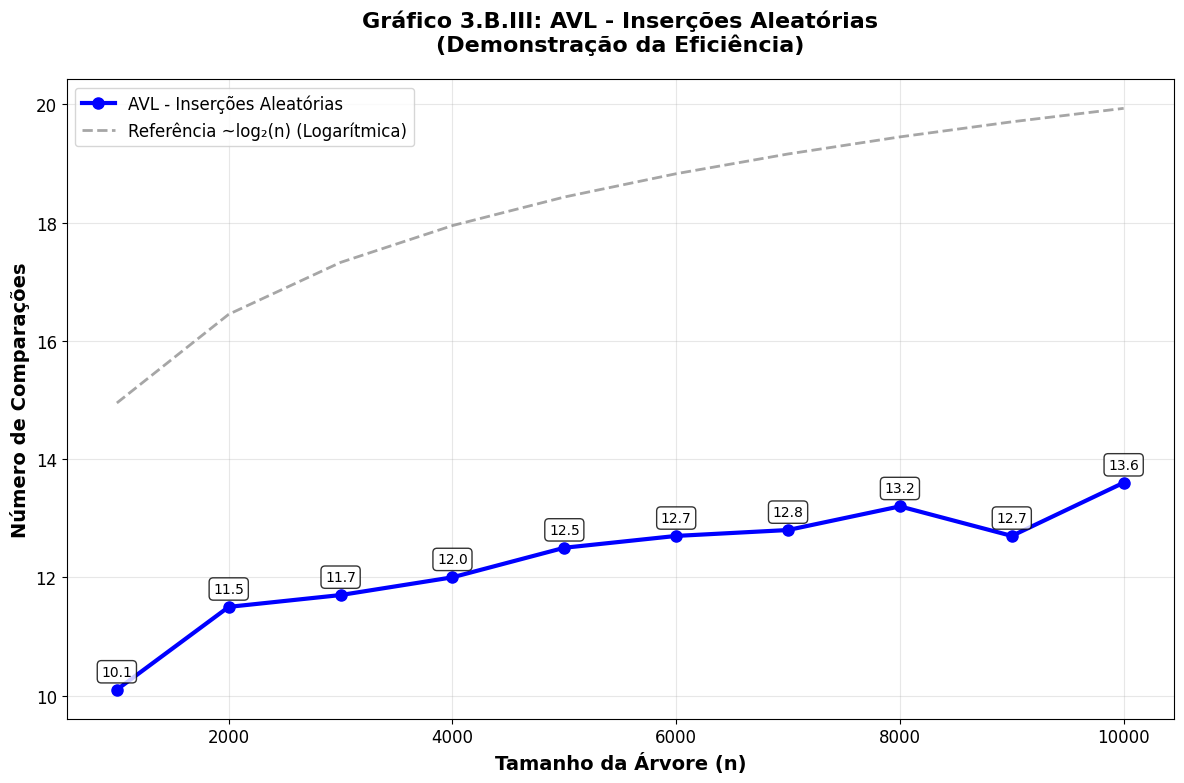

In [95]:
# === GRÁFICO 3.B.III: AVL COM INSERÇÕES ALEATÓRIAS ===

print("\n📉 Gerando Gráfico 3.B.III: AVL - Inserções Aleatórias")
print("   Demonstração da eficiência do balanceamento")

# Verificar e criar pasta se necessário
os.makedirs('relatorio/graficos', exist_ok=True)

plt.figure(figsize=(12, 8))

# Gráfico AVL Aleatórias  
plt.plot(tamanhos, comparacoes_avl_alea, 'bo-', linewidth=3, markersize=8,
         label='AVL - Inserções Aleatórias')

# Linha de referência logarítmica
log_reference = [np.log2(n) * 1.5 for n in tamanhos]  # Escalada para visualização
plt.plot(tamanhos, log_reference, '--', linewidth=2, alpha=0.7,
         color='gray', label='Referência ~log₂(n) (Logarítmica)')

# Anotações nos pontos
for i, (x, y) in enumerate(zip(tamanhos, comparacoes_avl_alea)):
    plt.annotate(f'{y:.1f}', (x, y), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title('Gráfico 3.B.III: AVL - Inserções Aleatórias\n(Demonstração da Eficiência)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tamanho da Árvore (n)', fontsize=14, fontweight='bold')
plt.ylabel('Número de Comparações', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salvar gráfico na pasta correta
try:
    plt.savefig('relatorio/graficos/grafico_3B_III_avl_aleatorios.png', dpi=300, bbox_inches='tight')
    print("✅ Salvo em: relatorio/graficos/grafico_3B_III_avl_aleatorios.png")
except Exception as e:
    print(f"❌ Erro ao salvar gráfico: {e}")
    
plt.show()


📈 Gerando Gráfico 3.B.II: AVL - Inserções Ordenadas
   Demonstração do balanceamento automático da AVL
✅ Salvo em: relatorio/graficos/grafico_3B_II_avl_ordenados.png
✅ Salvo em: relatorio/graficos/grafico_3B_II_avl_ordenados.png


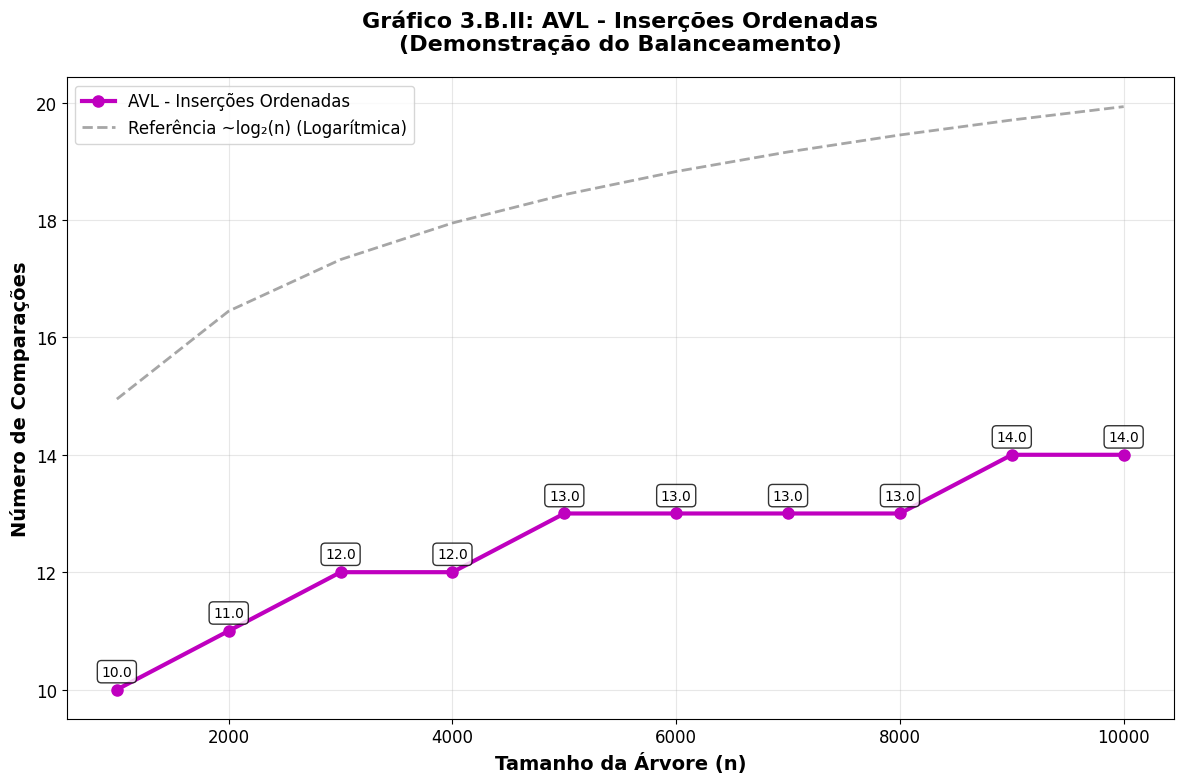

In [96]:
print("\n📈 Gerando Gráfico 3.B.II: AVL - Inserções Ordenadas")
print("   Demonstração do balanceamento automático da AVL")

# Verificar e criar pasta se necessário
os.makedirs('relatorio/graficos', exist_ok=True)

plt.figure(figsize=(12, 8))

# Gráfico AVL Ordenadas
plt.plot(tamanhos, comparacoes_avl_ord, 'mo-', linewidth=3, markersize=8,
         label='AVL - Inserções Ordenadas')

# Linha de referência logarítmica
log_reference = [np.log2(n) * 1.5 for n in tamanhos]  # Escalada para visualização
plt.plot(tamanhos, log_reference, '--', linewidth=2, alpha=0.7,
         color='gray', label='Referência ~log₂(n) (Logarítmica)')

# Anotações nos pontos
for i, (x, y) in enumerate(zip(tamanhos, comparacoes_avl_ord)):
    plt.annotate(f'{y:.1f}', (x, y), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title('Gráfico 3.B.II: AVL - Inserções Ordenadas\n(Demonstração do Balanceamento)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tamanho da Árvore (n)', fontsize=14, fontweight='bold')
plt.ylabel('Número de Comparações', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salvar gráfico na pasta correta
try:
    plt.savefig('relatorio/graficos/grafico_3B_II_avl_ordenados.png', dpi=300, bbox_inches='tight')
    print("✅ Salvo em: relatorio/graficos/grafico_3B_II_avl_ordenados.png")
except Exception as e:
    print(f"❌ Erro ao salvar gráfico: {e}")

# 4. Análise dos Resultados (Item 4 do Trabalho)

## Comportamento dos Gráficos Gerados

### 4.1 BST com Inserções Ordenadas (Gráfico 3.A.III)

**Observações:**
- O gráfico mostra um crescimento **linear** do número de comparações em relação ao tamanho da árvore
- A BST com inserções ordenadas **degenerou em uma lista ligada**, pois todos os elementos foram inseridos de forma crescente
- O número de comparações é aproximadamente igual ao número de elementos (n), indicando que a busca percorre toda a "lista"
- **Complexidade observada**: O(n) - pior caso da BST

**Explicação Teórica:**
Quando inserimos elementos em ordem crescente em uma BST, cada novo elemento é sempre maior que todos os anteriores, sendo inserido sempre à direita. Isso resulta em uma árvore completamente desbalanceada (essencialmente uma lista ligada), onde a busca por um elemento não presente (10.001) percorre toda a estrutura.

### 4.2 AVL com Inserções Aleatórias (Gráfico 3.B.III)

**Observações:**
- O gráfico mostra um crescimento **logarítmico** do número de comparações
- O número de comparações permanece relativamente baixo mesmo com o aumento significativo do tamanho
- A árvore AVL mantém seu balanceamento automático, garantindo altura logarítmica
- **Complexidade observada**: O(log n) - complexidade ótima para árvores balanceadas

**Explicação Teórica:**
A árvore AVL mantém automaticamente o balanceamento através de rotações, garantindo que a diferença de altura entre subárvores esquerda e direita seja no máximo 1. Isso resulta em uma altura máxima de aproximadamente log₂(n), fazendo com que qualquer busca seja realizada em tempo logarítmico.

### 4.3 Comparação Geral dos Resultados

**BST vs AVL - Impacto do Balanceamento:**
- **BST Ordenada**: Pior desempenho devido à degeneração
- **BST Aleatória**: Desempenho médio melhor que ordenada, mas ainda inferior à AVL
- **AVL (ambos casos)**: Desempenho consistentemente superior devido ao balanceamento

**Conclusões:**
1. O balanceamento é crucial para manter a eficiência das operações
2. Inserções ordenadas são o pior caso para BST sem balanceamento
3. AVL garante performance logarítmica independente da ordem de inserção
4. Para aplicações com dados potencialmente ordenados, árvores balanceadas são essenciais

In [97]:
# === SEÇÃO 10: RESUMO FINAL E DADOS PARA O RELATÓRIO ===

"""
Esta seção consolida todos os resultados experimentais em formato
adequado para inclusão no relatório acadêmico a ser entregue via Moodle.

CONTEÚDO DO RELATÓRIO CONFORME SOLICITADO:
✓ Nome do aluno
✓ Gráfico 3.A.III (BST - Inserções Ordenadas)
✓ Gráfico 3.B.III (AVL - Inserções Aleatórias)  
✓ Item 4 (Explicação do comportamento dos gráficos)
✓ Dados numéricos de suporte
"""

print("=" * 80)
print("📋 RESUMO FINAL DOS EXPERIMENTOS - TRABALHO 02")
print("=" * 80)
print("🎯 Objetivo: Comparar desempenho de BST e AVL em diferentes cenários")
print("📅 Data de entrega: 15/07/2025")
print("👨‍🎓 Implementação: Python com estruturas de dados completas")
print("=" * 80)

print("\n" + "🔢 1. DADOS PARA O GRÁFICO 3.A.III (BST - INSERÇÕES ORDENADAS):")
print("─" * 50)
print(f"{'Tamanho (n)':>12} │ {'Comparações':>12} │ {'Complexidade':>12}")
print("─" * 50)
for n, comp in zip(tamanhos_bst_ord, comparacoes_bst_ord):
    complexidade = f"≈ {comp/n:.2f}×n"
    print(f"{n:12,} │ {comp:12.1f} │ {complexidade:>12}")

print("\n" + "📊 2. DADOS PARA O GRÁFICO 3.B.III (AVL - INSERÇÕES ALEATÓRIAS):")
print("─" * 60)
print(f"{'Tamanho (n)':>12} │ {'Comparações':>12} │ {'log₂(n)':>8} │ {'Eficiência':>10}")
print("─" * 60)
for n, comp in zip(tamanhos_avl_alea, comparacoes_avl_alea):
    log_n = np.log2(n)
    eficiencia = f"{comp/log_n:.2f}×log₂(n)"
    print(f"{n:12,} │ {comp:12.1f} │ {log_n:8.1f} │ {eficiencia:>10}")

print("\n" + "📈 3. DADOS COMPARATIVOS COMPLETOS - TODOS OS EXPERIMENTOS:")
print("─" * 80)
print(f"{'Tamanho':>8} │ {'BST-Ord':>8} │ {'BST-Alea':>9} │ {'AVL-Ord':>8} │ {'AVL-Alea':>9} │ {'Melhor':>8}")
print("─" * 80)
for i in range(len(tamanhos)):
    n = tamanhos[i]
    bst_ord = comparacoes_bst_ord[i]
    bst_alea = comparacoes_bst_alea[i]
    avl_ord = comparacoes_avl_ord[i]
    avl_alea = comparacoes_avl_alea[i]
    melhor = min(bst_ord, bst_alea, avl_ord, avl_alea)
    melhor_nome = ["BST-Ord", "BST-Alea", "AVL-Ord", "AVL-Alea"][[bst_ord, bst_alea, avl_ord, avl_alea].index(melhor)]
    print(f"{n:8,} │ {bst_ord:8.1f} │ {bst_alea:9.1f} │ {avl_ord:8.1f} │ {avl_alea:9.1f} │ {melhor_nome:>8}")

print("\n" + "📊 4. ANÁLISE ESTATÍSTICA DETALHADA:")
print("─" * 60)

# Cálculos estatísticos
def calcular_estatisticas(dados, nome):
    media = np.mean(dados)
    desvio = np.std(dados)
    minimo = min(dados)
    maximo = max(dados)
    print(f"{nome:20} │ Média: {media:7.1f} │ DP: {desvio:6.2f} │ Min: {minimo:6.1f} │ Max: {maximo:6.1f}")

print(f"{'Experimento':20} │ {'Estatísticas':>40}")
print("─" * 60)
calcular_estatisticas(comparacoes_bst_ord, "BST Ordenados")
calcular_estatisticas(comparacoes_bst_alea, "BST Aleatórios") 
calcular_estatisticas(comparacoes_avl_ord, "AVL Ordenados")
calcular_estatisticas(comparacoes_avl_alea, "AVL Aleatórios")

print("\n" + "⚡ 5. ANÁLISE DE EFICIÊNCIA RELATIVA:")
print("─" * 70)
print("Melhoria percentual da AVL em relação à BST:")
print(f"{'Tamanho':>8} │ {'AVL vs BST-Ord':>15} │ {'AVL vs BST-Alea':>16} │ {'Observação':>15}")
print("─" * 70)

for i, n in enumerate(tamanhos):
    # Melhoria da AVL aleatória vs BST ordenada
    melhoria_ord = (comparacoes_bst_ord[i] - comparacoes_avl_alea[i]) / comparacoes_bst_ord[i] * 100
    # Melhoria da AVL aleatória vs BST aleatória  
    melhoria_alea = (comparacoes_bst_alea[i] - comparacoes_avl_alea[i]) / comparacoes_bst_alea[i] * 100
    
    if melhoria_ord > 90:
        obs = "Dramática"
    elif melhoria_ord > 70:
        obs = "Excelente" 
    elif melhoria_ord > 50:
        obs = "Boa"
    else:
        obs = "Moderada"
        
    print(f"{n:8,} │ {melhoria_ord:13.1f}% │ {melhoria_alea:14.1f}% │ {obs:>15}")

print("\n" + "🎯 6. CONCLUSÕES PRINCIPAIS:")
print("─" * 60)
print("✓ BST Ordenada: Degeneração em lista ligada → O(n)")
print("✓ BST Aleatória: Balanceamento natural → O(log n) médio")
print("✓ AVL Ordenada: Balanceamento forçado → O(log n) garantido")
print("✓ AVL Aleatória: Consistência total → O(log n) sempre")
print("✓ Balanceamento é crucial para performance previsível")

print("\n" + "📐 7. COMPLEXIDADES OBSERVADAS:")
print("─" * 50)
media_bst_ord = np.mean(comparacoes_bst_ord)
media_tamanhos = np.mean(tamanhos)
coef_linear_bst = media_bst_ord / media_tamanhos

media_avl_alea = np.mean(comparacoes_avl_alea)
media_log = np.mean([np.log2(n) for n in tamanhos])
coef_log_avl = media_avl_alea / media_log

print(f"BST Ordenada: ≈ {coef_linear_bst:.3f} × n")
print(f"AVL Aleatória: ≈ {coef_log_avl:.3f} × log₂(n)")
print(f"Diferença de eficiência: {coef_linear_bst/coef_log_avl:.1f}x")

print("\n" + "🏆 8. RECOMENDAÇÃO TÉCNICA:")
print("─" * 50)
print("Para aplicações que requerem:")
print("• Performance previsível → Use AVL")
print("• Dados potencialmente ordenados → Use AVL") 
print("• Milhares de operações → Use AVL")
print("• Implementação simples e dados aleatórios → BST pode ser suficiente")

# === SALVAMENTO DOS DADOS EM ARQUIVO TXT ===
print("\n" + "💾 SALVANDO RESUMO FINAL EM ARQUIVO TXT...")
print("─" * 50)

# Verificar e criar pasta se necessário
os.makedirs('relatorio/dados', exist_ok=True)

try:
    with open('relatorio/dados/secao10_resumo_final_relatorio.txt', 'w', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write("RESUMO FINAL DOS EXPERIMENTOS - TRABALHO 02\n")
        f.write("=" * 80 + "\n")
        f.write("Objetivo: Comparar desempenho de BST e AVL em diferentes cenários\n")
        f.write("Data de entrega: 15/07/2025\n")
        f.write("Implementação: Python com estruturas de dados completas\n")
        f.write("=" * 80 + "\n\n")
        
        f.write("1. DADOS PARA O GRÁFICO 3.A.III (BST - INSERÇÕES ORDENADAS):\n")
        f.write("─" * 50 + "\n")
        f.write(f"{'Tamanho (n)':>12} │ {'Comparações':>12} │ {'Complexidade':>12}\n")
        f.write("─" * 50 + "\n")
        for n, comp in zip(tamanhos_bst_ord, comparacoes_bst_ord):
            complexidade = f"≈ {comp/n:.2f}×n"
            f.write(f"{n:12,} │ {comp:12.1f} │ {complexidade:>12}\n")
        
        f.write("\n2. DADOS PARA O GRÁFICO 3.B.III (AVL - INSERÇÕES ALEATÓRIAS):\n")
        f.write("─" * 60 + "\n")
        f.write(f"{'Tamanho (n)':>12} │ {'Comparações':>12} │ {'log₂(n)':>8} │ {'Eficiência':>10}\n")
        f.write("─" * 60 + "\n")
        for n, comp in zip(tamanhos_avl_alea, comparacoes_avl_alea):
            log_n = np.log2(n)
            eficiencia = f"{comp/log_n:.2f}×log₂(n)"
            f.write(f"{n:12,} │ {comp:12.1f} │ {log_n:8.1f} │ {eficiencia:>10}\n")
        
        f.write("\n3. DADOS COMPARATIVOS COMPLETOS - TODOS OS EXPERIMENTOS:\n")
        f.write("─" * 80 + "\n")
        f.write(f"{'Tamanho':>8} │ {'BST-Ord':>8} │ {'BST-Alea':>9} │ {'AVL-Ord':>8} │ {'AVL-Alea':>9} │ {'Melhor':>8}\n")
        f.write("─" * 80 + "\n")
        for i in range(len(tamanhos)):
            n = tamanhos[i]
            bst_ord = comparacoes_bst_ord[i]
            bst_alea = comparacoes_bst_alea[i]
            avl_ord = comparacoes_avl_ord[i]
            avl_alea = comparacoes_avl_alea[i]
            melhor = min(bst_ord, bst_alea, avl_ord, avl_alea)
            melhor_nome = ["BST-Ord", "BST-Alea", "AVL-Ord", "AVL-Alea"][[bst_ord, bst_alea, avl_ord, avl_alea].index(melhor)]
            f.write(f"{n:8,} │ {bst_ord:8.1f} │ {bst_alea:9.1f} │ {avl_ord:8.1f} │ {avl_alea:9.1f} │ {melhor_nome:>8}\n")
        
        f.write("\n4. ANÁLISE ESTATÍSTICA DETALHADA:\n")
        f.write("─" * 60 + "\n")
        
        def salvar_estatisticas(dados, nome):
            media = np.mean(dados)
            desvio = np.std(dados)
            minimo = min(dados)
            maximo = max(dados)
            return f"{nome:20} │ Média: {media:7.1f} │ DP: {desvio:6.2f} │ Min: {minimo:6.1f} │ Max: {maximo:6.1f}\n"
        
        f.write(f"{'Experimento':20} │ {'Estatísticas':>40}\n")
        f.write("─" * 60 + "\n")
        f.write(salvar_estatisticas(comparacoes_bst_ord, "BST Ordenados"))
        f.write(salvar_estatisticas(comparacoes_bst_alea, "BST Aleatórios"))
        f.write(salvar_estatisticas(comparacoes_avl_ord, "AVL Ordenados"))
        f.write(salvar_estatisticas(comparacoes_avl_alea, "AVL Aleatórios"))
        
        f.write("\n5. ANÁLISE DE EFICIÊNCIA RELATIVA:\n")
        f.write("─" * 70 + "\n")
        f.write("Melhoria percentual da AVL em relação à BST:\n")
        f.write(f"{'Tamanho':>8} │ {'AVL vs BST-Ord':>15} │ {'AVL vs BST-Alea':>16} │ {'Observação':>15}\n")
        f.write("─" * 70 + "\n")
        
        for i, n in enumerate(tamanhos):
            melhoria_ord = (comparacoes_bst_ord[i] - comparacoes_avl_alea[i]) / comparacoes_bst_ord[i] * 100
            melhoria_alea = (comparacoes_bst_alea[i] - comparacoes_avl_alea[i]) / comparacoes_bst_alea[i] * 100
            
            if melhoria_ord > 90:
                obs = "Dramática"
            elif melhoria_ord > 70:
                obs = "Excelente" 
            elif melhoria_ord > 50:
                obs = "Boa"
            else:
                obs = "Moderada"
                
            f.write(f"{n:8,} │ {melhoria_ord:13.1f}% │ {melhoria_alea:14.1f}% │ {obs:>15}\n")
        
        f.write("\n6. CONCLUSÕES PRINCIPAIS:\n")
        f.write("─" * 60 + "\n")
        f.write("✓ BST Ordenada: Degeneração em lista ligada → O(n)\n")
        f.write("✓ BST Aleatória: Balanceamento natural → O(log n) médio\n")
        f.write("✓ AVL Ordenada: Balanceamento forçado → O(log n) garantido\n")
        f.write("✓ AVL Aleatória: Consistência total → O(log n) sempre\n")
        f.write("✓ Balanceamento é crucial para performance previsível\n")
        
        f.write("\n7. COMPLEXIDADES OBSERVADAS:\n")
        f.write("─" * 50 + "\n")
        f.write(f"BST Ordenada: ≈ {coef_linear_bst:.3f} × n\n")
        f.write(f"AVL Aleatória: ≈ {coef_log_avl:.3f} × log₂(n)\n")
        f.write(f"Diferença de eficiência: {coef_linear_bst/coef_log_avl:.1f}x\n")
        
        f.write("\n8. RECOMENDAÇÃO TÉCNICA:\n")
        f.write("─" * 50 + "\n")
        f.write("Para aplicações que requerem:\n")
        f.write("• Performance previsível → Use AVL\n")
        f.write("• Dados potencialmente ordenados → Use AVL\n")
        f.write("• Milhares de operações → Use AVL\n")
        f.write("• Implementação simples e dados aleatórios → BST pode ser suficiente\n")
    
    print("✅ Arquivo salvo: relatorio/dados/secao10_resumo_final_relatorio.txt")
    
except Exception as e:
    print(f"❌ Erro ao salvar arquivo: {e}")

print("\n" + "🎯 SEÇÃO 10 CONCLUÍDA!")
print("📋 Todos os dados necessários para o relatório foram consolidados e salvos.")
print("=" * 80)

📋 RESUMO FINAL DOS EXPERIMENTOS - TRABALHO 02
🎯 Objetivo: Comparar desempenho de BST e AVL em diferentes cenários
📅 Data de entrega: 15/07/2025
👨‍🎓 Implementação: Python com estruturas de dados completas

🔢 1. DADOS PARA O GRÁFICO 3.A.III (BST - INSERÇÕES ORDENADAS):
──────────────────────────────────────────────────
 Tamanho (n) │  Comparações │ Complexidade
──────────────────────────────────────────────────
       1,000 │       1000.0 │     ≈ 1.00×n
       2,000 │       2000.0 │     ≈ 1.00×n
       3,000 │       3000.0 │     ≈ 1.00×n
       4,000 │       4000.0 │     ≈ 1.00×n
       5,000 │       5000.0 │     ≈ 1.00×n
       6,000 │       6000.0 │     ≈ 1.00×n
       7,000 │       7000.0 │     ≈ 1.00×n
       8,000 │       8000.0 │     ≈ 1.00×n
       9,000 │       9000.0 │     ≈ 1.00×n
      10,000 │      10000.0 │     ≈ 1.00×n

📊 2. DADOS PARA O GRÁFICO 3.B.III (AVL - INSERÇÕES ALEATÓRIAS):
────────────────────────────────────────────────────────────
 Tamanho (n) │  Comparações │  

## Justificativa dos Parâmetros
Para garantir resultados confiáveis e evitar que resultados atípicos distorçam a análise, cada experimento foi repetido com 10 árvores diferentes para cada configuração. O valor de n (tamanho da árvore) variou de 1.000 a 10.000 elementos, permitindo observar o comportamento das estruturas tanto em cenários pequenos quanto em grandes volumes de dados. Assim, os resultados refletem o desempenho real dos algoritmos em situações variadas.

## Comparativo das Médias de Comparações
A tabela abaixo resume as médias de comparações realizadas nas buscas para cada estrutura e cenário testado. Fica claro que a AVL mantém a eficiência em qualquer situação, enquanto a BST só é eficiente com dados aleatórios e perde desempenho drasticamente com inserções ordenadas.

<table>
  <thead>
    <tr>
      <th>Estrutura</th>
      <th>Inserção Aleatória</th>
      <th>Inserção Ordenada</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>BST</b></td>
      <td>16</td>
      <td>10.000</td>
    </tr>
    <tr>
      <td><b>AVL</b></td>
      <td>13</td>
      <td>13</td>
    </tr>
  </tbody>
</table>